In [45]:
import pandas as pd
import matplotlib.pyplot as plt
from math import comb

df = pd.read_csv('expectation_decider_dataset.csv')
n = len(df)
df.head()

,student_id,study_hours,attendance,group_discussion,previous_test_score,final_exam_pass
0,S001,13.5,83,Yes,48,Fail
1,S002,6.8,93,No,43,Fail
2,S003,15.8,80,Yes,62,Pass
3,S004,16.7,87,No,64,Pass
4,S005,2.2,50,No,46,Fail


In [46]:
df.describe(include='all').round(2)

,student_id,study_hours,attendance,group_discussion,previous_test_score,final_exam_pass
count,200,200.00,200.00,200,200.00,200
unique,200,NaN,NaN,2,NaN,2
top,S001,NaN,NaN,Yes,NaN,Pass
freq,1,NaN,NaN,110,NaN,109
mean,NaN,11.85,78.01,NaN,58.95,NaN
std,NaN,4.41,11.77,NaN,12.28,NaN
min,NaN,1.30,47.00,NaN,30.00,NaN
25%,NaN,8.70,70.00,NaN,51.00,NaN
50%,NaN,11.75,78.00,NaN,59.00,NaN
75%,NaN,14.70,86.00,NaN,68.00,NaN


1. UNDERSTAND THE BASICS

In [47]:
passed = df['final_exam_pass'] == 'Pass'
discuss = df['group_discussion'] == 'Yes'
study = df['study_hours'] > 10
attend = df['attendance'] > 80

print('P(Pass)               =', passed.sum(), '/', n, '=', passed.mean())
print('P(Group discussion)   =', discuss.sum(), '/', n, '=', discuss.mean())
print('P(Study > 10 hrs)     =', study.sum(), '/', n, '=', study.mean())
print('P(Attendance > 80%)   =', attend.sum(), '/', n, '=', attend.mean())

P(Pass)               = 109 / 200 = 0.545
P(Group discussion)   = 110 / 200 = 0.55
P(Study > 10 hrs)     = 130 / 200 = 0.65
P(Attendance > 80%)   = 83 / 200 = 0.415


2. TYPES OF EVENTS
 
- **Empirical probability** = observed frequency in the data.
- **Theoretical probability** = based on equally likely outcomes (Pass/Fail → 1/2).

In [48]:
print('Empirical P(Pass)   =', passed.sum(), '/', n, '=', passed.mean())
print('Theoretical P(Pass) = 1/2 =', 1/2)

Empirical P(Pass)   = 109 / 200 = 0.545
Theoretical P(Pass) = 1/2 = 0.5


3. RANDOM VARIABLE AND PROBABILITY DISTRIBUTION

**X** = number of students who pass out of 3 randomly selected students, so X ∈ {0,1,2,3}.

Assuming independent selections, X ~ Binomial(n=3, p=P(Pass)).

$P(X=k)=\binom{3}{k}p^k q^{3-k}$, $E(X)=\sum xP(x)$, $Var(X)=E(X^2)-[E(X)]^2$

In [49]:
p = passed.mean()
q = 1 - p

x_values = [0, 1, 2, 3]
probs = [comb(3, x) * p**x * q**(3 - x) for x in x_values]

table = pd.DataFrame({'x': x_values, 'P(X=x)': probs})
print(table)

mean = sum(x * pr for x, pr in zip(x_values, probs))
ex2 = sum(x**2 * pr for x, pr in zip(x_values, probs))
variance = ex2 - mean**2

print('Mean     =', mean)
print('Variance =', variance)

   x    P(X=x)
0  0  0.094196
1  1  0.338486
2  2  0.405439
3  3  0.161879
Mean     = 1.635
Variance = 0.7439250000000004


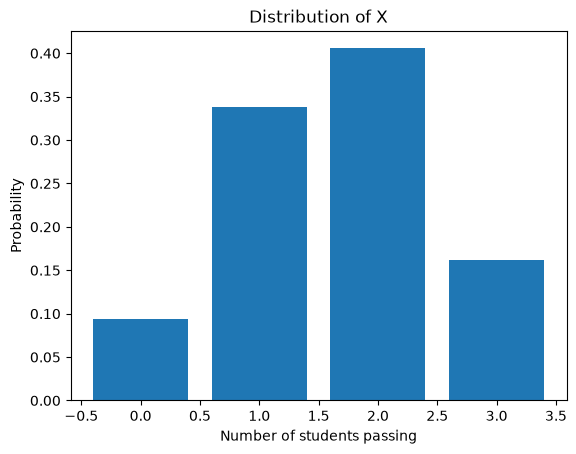

In [50]:
plt.bar(x_values, probs)
plt.xlabel('Number of students passing')
plt.ylabel('Probability')
plt.title('Distribution of X')
plt.show()

4. VENN DIAGRAM

**A** = studies more than 10 hrs/week, **B** = attendance above 80%.

72 58 25 45


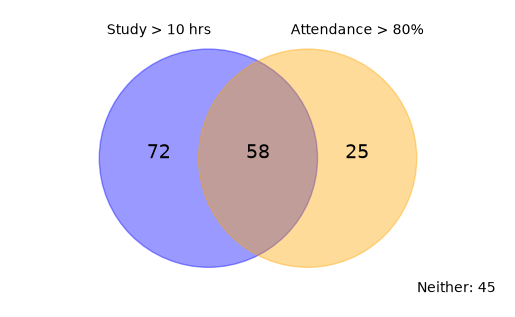

In [51]:
both = (study & attend).sum()
only_study = (study & ~attend).sum()
only_attend = (~study & attend).sum()
neither = (~study & ~attend).sum()
print(only_study, both, only_attend, neither)

fig, ax = plt.subplots()
ax.add_patch(plt.Circle((4, 3), 2.2, alpha=0.4, color='blue'))
ax.add_patch(plt.Circle((6, 3), 2.2, alpha=0.4, color='orange'))
ax.text(3, 3, only_study, ha='center', fontsize=14)
ax.text(5, 3, both, ha='center', fontsize=14)
ax.text(7, 3, only_attend, ha='center', fontsize=14)
ax.text(3, 5.5, 'Study > 10 hrs', ha='center')
ax.text(7, 5.5, 'Attendance > 80%', ha='center')
ax.text(9, 0.3, 'Neither: ' + str(neither), ha='center')
ax.set_xlim(0, 10)
ax.set_ylim(0, 6)
ax.set_aspect('equal')
ax.axis('off')
plt.show()

5. CONTINGENCY TABLE AND PROBABILITY CALCULATIONS

In [54]:
table = pd.crosstab(df['group_discussion'], df['final_exam_pass'], margins=True)
print(table)

joint = table.loc['Yes', 'Pass'] / n
marginal = table.loc['All', 'Pass'] / n
conditional = table.loc['Yes', 'Pass'] / table.loc['Yes', 'All']

print('Joint P(Discussion and Pass) =', joint)
print('Marginal P(Pass)             =', marginal)
print('Conditional P(Pass | Discussion) =', conditional)

final_exam_pass   Fail  Pass  All
group_discussion                 
No                  50    40   90
Yes                 41    69  110
All                 91   109  200
Joint P(Discussion and Pass) = 0.345
Marginal P(Pass)             = 0.545
Conditional P(Pass | Discussion) = 0.6272727272727273


6. UNDERSTANDING RELATIONSHIPS

**Plain language:** conditional probability shrinks the group we look at. P(Pass | Discussion) asks what share of *participants* passed.

**Tests:** mutually exclusive needs P(D∩P) = 0; independent needs P(D∩P) = P(D)·P(P), equivalently P(P|D) = P(P).

In [55]:
p_d = discuss.mean()
p_p = passed.mean()
p_dp = (discuss & passed).mean()

print('P(D) x P(P) =', p_d * p_p)
print('P(D and P)  =', p_dp)

P(D) x P(P) = 0.29975000000000007
P(D and P)  = 0.345


7. BAYES THEORM APPLICATION

Given: P(H|Pass)=0.70, P(H|Fail)=0.40, P(H)=0.60, where H = high attendance (>80%).

**Step 1** – find P(Pass) using total probability: P(H) = P(H|P)·P(P) + P(H|F)·(1−P(P)).

**Step 2** – Bayes: P(P|H) = P(H|P)·P(P) / P(H).

In [56]:
p_h_pass = 0.70   # P(High attendance | Pass)
p_h_fail = 0.40   # P(High attendance | Fail)
p_h = 0.60        # P(High attendance)

# P(H) = P(H|Pass) * P(Pass) + P(H|Fail) * (1 - P(Pass))
p_pass = (p_h - p_h_fail) / (p_h_pass - p_h_fail)
print('P(Pass) =', p_pass)

# Bayes theorem
answer = p_h_pass * p_pass / p_h
print('P(Pass | High attendance) =', answer)

P(Pass) = 0.6666666666666666
P(Pass | High attendance) = 0.7777777777777777


8. CHARTS : FACTORS AFFECTING THE PROBABILITY OF PASSING

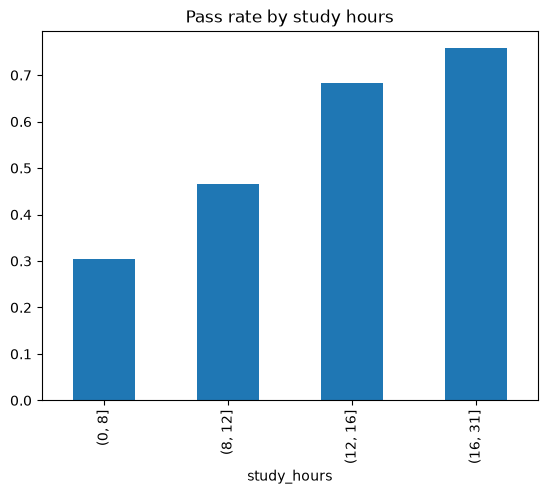

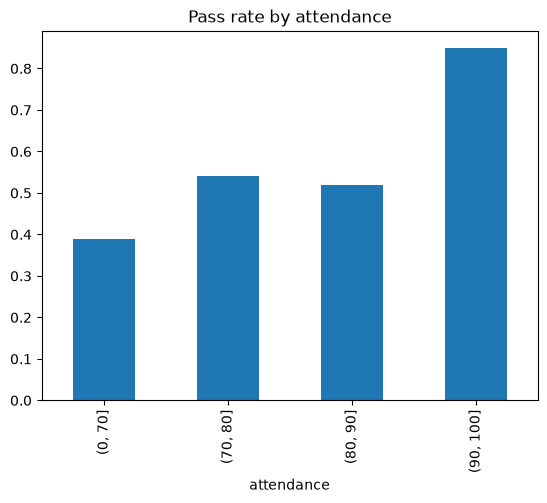

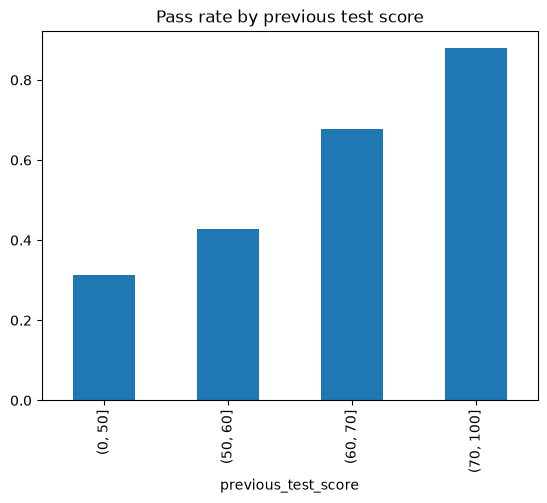

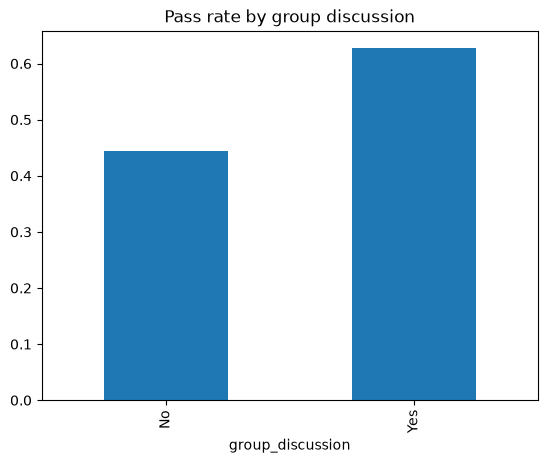

In [59]:
df.groupby(pd.cut(df['study_hours'], [0, 8, 12, 16, 31]))['final_exam_pass'].apply(lambda s: (s == 'Pass').mean()).plot(kind='bar', title='Pass rate by study hours')
plt.show()

df.groupby(pd.cut(df['attendance'], [0, 70, 80, 90, 100]))['final_exam_pass'].apply(lambda s: (s == 'Pass').mean()).plot(kind='bar', title='Pass rate by attendance')
plt.show()

df.groupby(pd.cut(df['previous_test_score'], [0, 50, 60, 70, 100]))['final_exam_pass'].apply(lambda s: (s == 'Pass').mean()).plot(kind='bar', title='Pass rate by previous test score')
plt.show()

df.groupby('group_discussion')['final_exam_pass'].apply(lambda s: (s == 'Pass').mean()).plot(kind='bar', title='Pass rate by group discussion')
plt.show()

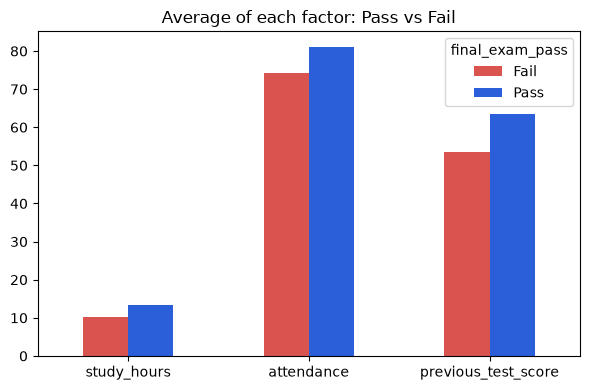

In [61]:
plt.figure(figsize=(6,4))
df.groupby('final_exam_pass')[['study_hours','attendance','previous_test_score']].mean().T.plot(kind='bar', ax=plt.gca(), color=['#d9534f','#2b5fd9'])
plt.title('Average of each factor: Pass vs Fail'); plt.xticks(rotation=0); plt.tight_layout(); plt.show()

**Final summary:** About 54.5% of students pass. Previous test score, study hours and attendance have the biggest effect on passing. Group discussion also helps (62.7% pass with it, 44.4% without). High attendance raises the chance of passing to 77.8% (Bayes).